# locally weighted logistic reggression

$$
\begin{aligned}
&\text{Hypothesis:} && h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}} \\[2mm]
&\text{Weight for each training example:} && w^{(i)} = \exp\Big( -\frac{ \| x - x^{(i)} \|^2 }{2 \tau^2} \Big) \\[1mm]
&\text{Weighted cost function:} && J(\theta) = - \sum_{i=1}^{m} w^{(i)} \Big[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \Big] \\[1mm]
&\text{Weighted gradient:} && \nabla_\theta J(\theta) = \sum_{i=1}^{m} w^{(i)} \big( h_\theta(x^{(i)}) - y^{(i)} \big) x^{(i)} \\[1mm]
&\text{Gradient descent update:} && \theta := \theta - \alpha \sum_{i=1}^{m} w^{(i)} \big( h_\theta(x^{(i)}) - y^{(i)} \big) x^{(i)}
\end{aligned}
$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

X = np.loadtxt("C:\\Users\\USER\\Downloads\\PS1-data\\q2\\data\\x.dat")
y = np.loadtxt("C:\\Users\\USER\\Downloads\\PS1-data\\q2\\data\\y.dat")
pd.DataFrame(X).info()


<class 'pandas.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       69 non-null     float64
 1   1       69 non-null     float64
dtypes: float64(2)
memory usage: 1.2 KB


In [ ]:
def lwlr(X, y, tau, x):
    m, n = X.shape
    theta = np.zeros((n, 1))
    lamda = 1e-4
    y = y.reshape(-1, 1)

    x_query = np.repeat(x.reshape(1, -1), m, axis=0)
    Weights = np.exp(-np.sum((x_query - X)**2, axis=1) / (2 * tau**2))
    Weights = Weights.reshape(-1, 1)

    g = np.ones((n, 1))

    while np.linalg.norm(g) > 1e-6:
        h = 1 / (1 + np.exp(-X @ theta))

        # Gradient
        g = X.T @ (Weights * (y - h)) - lamda * theta

        # Hessian
        W = np.diag((Weights.flatten()) * h.flatten() * (1 - h.flatten()))
        H = - X.T @ W @ X - lamda * np.eye(n)

        theta -= np.linalg.solve(H, g)

    y_pred = 1 / (1 + np.exp(-x.T @ theta))
    return int(y_pred.item() >= 0.5)



In [54]:
def plot_lwlr(X, y, tau, res):

    x = np.zeros((2,1))
    pred = np.zeros((res,res))

    for i in range(res):
        for j in range(res):
            x[0] = 2*(i-1)/(res-1) - 1
            x[1] = 2*(j-1)/(res-1) - 1
            pred[i,j] = lwlr(X, y, tau, x)

    plt.figure(figsize=(8,6))
    plt.clf()

    # Smooth background
    plt.imshow(pred.T,
               origin="lower",
               extent=[-1,1,-1,1],
               cmap="inferno",
               alpha=0.6,
               interpolation="bicubic",
               vmin=0, vmax=1)

    # Decision boundary
    plt.contour(
        np.linspace(-1,1,res),
        np.linspace(-1,1,res),
        pred.T,
        levels=[0.5],
        colors="black",
        linewidths=2
    )

    # Class 0
    X0 = X[y==0]
    plt.scatter(
        X0[:,0], X0[:,1],
        c="blue",
        marker="o",
        edgecolor="black",
        s=60,
        label="Class 0"
    )

    # Class 1
    X1 = X[y==1]
    plt.scatter(
        X1[:,0], X1[:,1],
        c="red",
        marker="x",
        s=70,
        label="Class 1"
    )

    plt.title(f"Locally Weighted Logistic Regression (tau = {tau})", fontsize=14)
    plt.xlabel("x1", fontsize=12)
    plt.ylabel("x2", fontsize=12)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

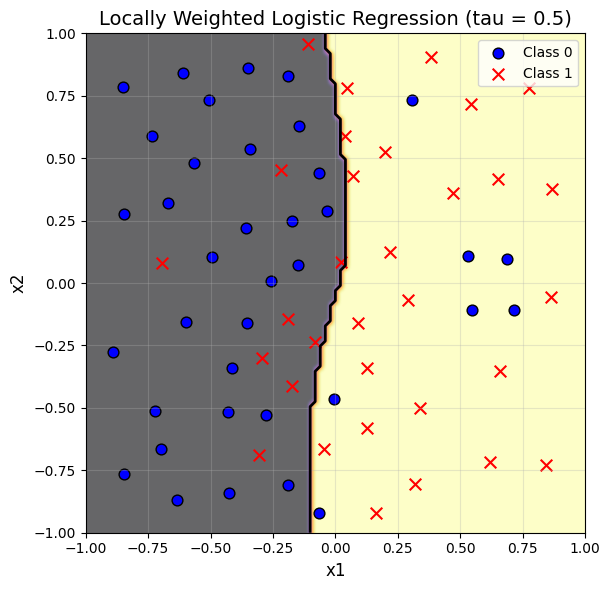

In [55]:
plot_lwlr(X, y, 0.5, 100)